# **User Behavior & Conversion Analysis**
### **Understanding Why Users Drop Off Before Completing a Purchase**

---
## **Problem Statement**

Over the past several months, an E-Commerce platform has observed a concerning pattern — user traffic remains healthy, but the overall conversion rate is significantly lower than expected.

This indicates that users are actively visiting and engaging with the platform, but a large proportion are **dropping off before completing a purchase**, directly impacting revenue.

To address this, we analyze the data to:
- Understand where in the journey users are exiting
- Identify behavioral and demographic factors that influence purchase decisions
- Provide actionable, data-backed recommendations to improve conversion

---

## **Key Questions**

#### 1. Where are users dropping off in the funnel?
- What percentage of sessions exist at each stage: Home → Product → Cart → Purchase?
- Which stage has the highest drop-off rate?

#### 2. What factors influence conversion?
- Does device type affect conversion rates?
- Which referral source drives the highest conversions?

#### 3. How does user behavior impact purchase decisions?
- Do users who spend more time on the platform convert at a higher rate?
- Is there a relationship between items added to cart and likelihood of purchase?

---

## **Assumptions**

Before beginning the analysis, the following hypotheses are stated.
These will be tested and either supported or challenged by the data:

1. **Funnel drop-off is steepest between Product and Cart** —
   most users who explore products still do not add items to cart

2. **Mobile users convert at a lower rate than Desktop users** —
   smaller screens and less convenient checkout flows

3. **Users who spend more time on the page are more likely to purchase** —
   higher time-on-page is expected to signal stronger purchase intent

4. **Ads-driven traffic converts better than Social or Direct** —
   paid traffic is typically more targeted and intent-driven

5. **Sessions with more items in cart have a higher purchase rate** —
   a fuller cart reflects stronger commitment to buying

---

## Approach

The analysis follows a step-by-step process to systematically
understand user behavior and identify conversion bottlenecks:

1. **Define the funnel stages** — Home → Product → Cart → Purchase
   and measure session volume at each stage

2. **Quantify drop-off** between each consecutive stage to find
   where the largest user loss occurs

3. **Segment the drop-off** by device type and referral source
   to understand which user groups are most affected

4. **Analyze behavioral patterns** — examine how time spent on
   page and items added to cart relate to likelihood of purchase

5. **Examine time-based trends** — identify monthly and day-of-week
   patterns in session volume and conversion rate

6. **Validate each finding statistically** — Chi-Square tests for
   categorical variables and Mann-Whitney U for behavioral variables
   to ensure findings are not due to chance

7. **Translate findings into prioritised recommendations** —
   each insight is mapped to a specific, actionable suggestion
   ranked by business impact

---

## **About the Dataset**

The dataset contains 13000 rows across 9 columns.
Each row represents a single user session and contains information about the user's behavior, device, traffic source, and final purchase outcome.

### **Column Descriptions**

| Column | Description |
|--------|-------------|
| `SessionID` | Unique identifier for each session (S1, S2, … S13000) |
| `UserID` | Unique identifier for the user |
| `Timestamp` | Date and time of the session |
| `PageType` |Page visited during the session: Home, Product, or Cart |
| `DeviceType` | Device used: Mobile, Desktop, or Tablet |
| `ReferralSource` | How the user arrived: Direct, Ads, or Social |
| `TimeOnPage_seconds` | Total time spent on the page (in seconds) |
| `ItemsInCart` | Number of items added to cart |
| `Purchased` | 1 = Purchase made, 0 = No purchase |

<br>

> ⚠️ **Note:** This dataset is synthetically generated for analytical
> purposes. Each row represents a single page-level session visit —
> funnel stages are approximated using session distribution, not a
> sequential user journey. Absolute values and conversion rates may
> not mirror real-world platform performance. Insights should be
> validated against real data before implementation.

---

## **Funnel Analysis**

A conversion funnel tracks user progression from first visit to
completed purchase. It is called a funnel because it is wide at
the top (many visitors) and narrow at the bottom (few conversions)
— with users dropping off at each stage.

Identifying where the largest drop occurs tells us exactly where to focus improvement efforts.

### **Our Funnel Stages**

```
┌─────────────────────────────┐
│         HOME PAGE           │   ← All visitors land here
└────────────┬────────────────┘
             │  Drop-off ↓
┌────────────▼────────────────┐
│       PRODUCT PAGE          │   ← Users who explore products
└────────────┬────────────────┘
             │  Drop-off ↓
┌────────────▼────────────────┐
│        CART PAGE            │   ← Users with purchase intent
└────────────┬────────────────┘
             │  Drop-off ↓
┌────────────▼────────────────┐
│        PURCHASED            │   ← Successful conversions
└─────────────────────────────┘
```
---

### **1. DATA PREPARATION**

### 1.1 — Importing Libraries

In [1]:
# ── DATA MANIPULATION ─────────────────────────────────────────────────────────
import pandas as pd                        # Core library for data loading, cleaning, and transformation
import numpy as np                         # Numerical operations and array handling

# ── DATA VISUALISATION ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt            # Base plotting library — figures, axes, layout control
import matplotlib.ticker as mticker        # Custom axis tick formatting
import seaborn as sns                      # Statistical visualisation built on matplotlib — cleaner charts

# ── STATISTICAL TESTING ───────────────────────────────────────────────────────
from scipy import stats                    # Comprehensive statistics: Chi-Square, Mann-Whitney U, T-tests
from scipy.stats import chi2_contingency   # Chi-Square test for categorical independence
from scipy.stats import mannwhitneyu       # Mann-Whitney U test for non-parametric group comparison

# ── NOTEBOOK DISPLAY SETTINGS ─────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')          # Suppress non-critical warnings for cleaner output

pd.set_option('display.max_columns', None)            # Show all columns when printing DataFrames
pd.set_option('display.float_format', '{:.2f}'.format) # Round floats to 2 decimal places in display

# ── PLOT STYLING ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')      # Clean white background with muted colour palette
plt.rcParams['figure.dpi'] = 120                       # Higher resolution for sharper notebook charts
plt.rcParams['font.family'] = 'sans-serif'             # Consistent font across all plots

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


### 1.2 — Load the Dataset

In [2]:
df = pd.read_csv('Ecommerce_Funnel_Dataset.csv')

# Preview the first 5 rows
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
df.head()

Shape: 13,000 rows × 9 columns



,SessionID,UserID,Timestamp,PageType,DeviceType,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,S1,U125,2024-10-14 23:45:05,Home,Mobile,Ads,43,0,0
1,S2,U189,2024-08-17 07:47:20,Home,Mobile,Direct,56,0,0
2,S3,U716,2024-01-11 07:19:59,Home,Desktop,Ads,33,0,0
3,S4,U325,2024-06-23 10:55:54,Home,Desktop,Direct,19,0,0
4,S5,U814,2024-06-13 03:03:06,Home,Mobile,Social,47,0,0


The dataset contains:
- 13,000 sessions
- 9 columns

In [3]:
# ── UNIQUE USERS ───────────────────────────────────────────────────────
print(f"  Unique Users : {df['UserID'].nunique():,}")

  Unique Users : 900


### 1.3 — Data Structure

In [4]:
# ── SHAPE ─────────────────────────────────────────────────────────────────────
print("Dataset Shape:")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print("━" * 45)
# ── COLUMN NAMES & DATA TYPES ─────────────────────────────────────────────────
print("Column Overview:")
col_info = pd.DataFrame({
    'Column'   : df.columns,
    'Dtype'    : df.dtypes.values,
    'Non-Null' : df.notnull().sum().values
})
print(col_info.to_string(index=False))

Dataset Shape:
  Rows    : 13,000
  Columns : 9
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Column Overview:
            Column  Dtype  Non-Null
         SessionID object     13000
            UserID object     13000
         Timestamp object     13000
          PageType object     13000
        DeviceType object     13000
    ReferralSource object     13000
TimeOnPage_seconds  int64     13000
       ItemsInCart  int64     13000
         Purchased  int64     13000


The following columns require data type correction before analysis (1.8 — Feature Engineering):
| Column         | Should Be   | Reason                          |
|----------------|-------------|---------------------------------|
| Timestamp      | datetime64  | Needed for time-based analysis  |
| PageType       | category    | Fixed set of 3 values           |
| DeviceType     | category    | Fixed set of 3 values           |
| ReferralSource | category    | Fixed set of 3 values           |
| Purchased      | bool/uint8  | Binary flag (0 or 1 only)       |



### 1.4 — Data Sanity Check

In [5]:
# ── MISSING VALUES ─────────────────────────────────────────────────────────────
print("Missing Values per Column:\n")
missing = df.isnull().sum()
missing_report = pd.DataFrame({'Missing Count': missing})
print(missing_report)
print(f"\n{'No missing values found.' if missing.sum() == 0 else 'Missing values detected — requires treatment.'}")

Missing Values per Column:

                    Missing Count
SessionID                       0
UserID                          0
Timestamp                       0
PageType                        0
DeviceType                      0
ReferralSource                  0
TimeOnPage_seconds              0
ItemsInCart                     0
Purchased                       0

No missing values found.


In [6]:
# ── DUPLICATE ROWS ─────────────────────────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f"Duplicate Rows: {dup_count}")
print(f"{'No duplicate rows found.' if dup_count == 0 else f'{dup_count} duplicates detected — requires removal.'}")

Duplicate Rows: 0
No duplicate rows found.


### 1.5 — Data Type Correction

In [7]:
# ── TIMESTAMP → datetime64 ────────────────────────────────────────────────────
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# ── CATEGORICAL COLUMNS ───────────────────────────────────────────────────────
cat_cols = ['PageType', 'DeviceType', 'ReferralSource']
for col in cat_cols:
    df[col] = df[col].astype('category')

# ── PURCHASED → bool ──────────────────────────────────────────────────────────
# Binary flag — bool is the correct representation for a 0/1 outcome column
df['Purchased'] = df['Purchased'].astype(bool)

# ── VERIFY ────────────────────────────────────────────────────────────────────
print("Data types after correction:\n")
print(df.dtypes)

Data types after correction:

SessionID                     object
UserID                        object
Timestamp             datetime64[ns]
PageType                    category
DeviceType                  category
ReferralSource              category
TimeOnPage_seconds             int64
ItemsInCart                    int64
Purchased                       bool
dtype: object


In [8]:
# ── DATA COVERAGE RANGE ───────────────────────────────────────────────────────
print("Data Coverage:")
print(f"  From           : {df['Timestamp'].min().strftime('%d %B %Y')}")
print(f"  To             : {df['Timestamp'].max().strftime('%d %B %Y')}")

Data Coverage:
  From           : 01 January 2024
  To             : 31 December 2024


The datset has sessions from 01st January 2024 to 31st December 2024


### 1.6 — Statistical Summary

In [9]:
# ── NUMERIC SUMMARY ───────────────────────────────────────────────────────────
print("Numeric Columns — Descriptive Statistics:\n")
numeric_summary = df[['TimeOnPage_seconds', 'ItemsInCart']].describe().T
print(numeric_summary)

Numeric Columns — Descriptive Statistics:

                      count  mean   std  min   25%   50%   75%    max
TimeOnPage_seconds 13000.00 65.75 57.91 5.00 26.00 46.00 90.00 299.00
ItemsInCart        13000.00  0.55  1.02 0.00  0.00  0.00  1.00   6.00


**TimeOnPage_seconds**  → Sessions range from 5s to 299s, with a mean of 65.7s
                      and median of 46s — indicating a right-skewed distribution

**ItemsInCart**        → Ranges from 0 to 6, with a median of 0 —
                      reflecting that most sessions carry no cart activity

In [10]:
# ── CATEGORICAL SUMMARY ───────────────────────────────────────────────────────
print("Categorical Columns — Value Distribution:\n")
for col in ['PageType', 'DeviceType', 'ReferralSource']:
    counts = df[col].value_counts()
    pct    = df[col].value_counts(normalize=True).mul(100).round(1)
    table  = pd.DataFrame({'Sessions': counts, 'Share (%)': pct})
    print(f"{col}:")
    print(table.to_string())
    print("━" * 45)

Categorical Columns — Value Distribution:

PageType:
          Sessions  Share (%)
PageType                     
Home          7791      59.90
Product       3943      30.30
Cart          1266       9.70
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DeviceType:
            Sessions  Share (%)
DeviceType                     
Mobile          7773      59.80
Desktop         3897      30.00
Tablet          1330      10.20
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ReferralSource:
                Sessions  Share (%)
ReferralSource                     
Direct              6420      49.40
Ads                 3990      30.70
Social              2590      19.90
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


**PageType**     → Sessions are spread across three funnel stages —
                Home (59.9%), Product (30.3%), and Cart (9.7%)

**DeviceType**   → Mobile is the dominant device at 59.8%, followed by
                Desktop (30%) and Tablet (10.2%)

**ReferralSource** → Nearly half of all traffic arrives directly (49.4%).
                 Ads drive 30.7% and Social accounts for 19.9%

In [11]:
# ── TARGET VARIABLE ───────────────────────────────────────────────────────────
print("Target Variable — Purchased:\n")
purchase_counts = df['Purchased'].value_counts()
print(f"  Did Not Purchase : {purchase_counts[False]:,}  ({purchase_counts[False]/len(df)*100:.1f}%)")
print(f"  Purchased        : {purchase_counts[True]:,}    ({purchase_counts[True]/len(df)*100:.1f}%)")
print(f"  Conversion Rate  : {df['Purchased'].mean()*100:.2f}%")

Target Variable — Purchased:

  Did Not Purchase : 12,243  (94.2%)
  Purchased        : 757    (5.8%)
  Conversion Rate  : 5.82%


94.2% of sessions did not result in a purchase, with an overall
conversion rate of 5.82% — consistent with typical e-commerce benchmarks.

### 1.7 — Funnel Logic Validation

In [12]:
# ── FUNNEL LOGIC VALIDATION ────────────────────────────────────────────────────
# Rule 1: Purchased = 1 should ONLY appear on Cart pages
invalid_purchase_page = df[(df['Purchased'] == True) & (df['PageType'] != 'Cart')]

# Rule 2: ItemsInCart > 0 should NOT appear on Home pages
invalid_cart_on_home = df[(df['ItemsInCart'] > 0) & (df['PageType'] == 'Home')]

# Rule 3: Purchased = 1 should NOT have ItemsInCart = 0
invalid_bought_empty = df[(df['Purchased'] == 1) & (df['ItemsInCart'] == 0)]

# ── VALIDATION REPORT ─────────────────────────────────────────────────────────
validation = pd.DataFrame({
    'Rule'    : [
        'Purchases only on Cart page',
        'No cart items on Home page',
        'Purchases have at least 1 item in cart'
    ],
    'Violations' : [
        len(invalid_purchase_page),
        len(invalid_cart_on_home),
        len(invalid_bought_empty)
    ]
})

validation['Status'] = validation['Violations'].apply(
    lambda x: 'PASS' if x == 0 else 'FAIL'
)

print("Funnel Logic Validation\n")
print(validation.to_string(index=False))
print("\nAll rules passed")

Funnel Logic Validation

                                  Rule  Violations Status
           Purchases only on Cart page           0   PASS
            No cart items on Home page           0   PASS
Purchases have at least 1 item in cart           0   PASS

All rules passed


### 1.8 — Feature Engineering

In [13]:
# ── EXTRACT DATE & TIME COMPONENTS FROM TIMESTAMP ─────────────────────────────
df['Date']      = df['Timestamp'].dt.date            # 2024-01-01, 2024-01-02...
df['Month']     = df['Timestamp'].dt.month_name()    # January, February...
df['DayOfWeek'] = df['Timestamp'].dt.day_name()      # Monday, Tuesday...
df['Hour']      = df['Timestamp'].dt.hour            # 0–23

In [14]:
# ── PREVIEW UPDATED DATAFRAME ─────────────────────────────────────────────────
print("Updated DataFrame preview:\n")
print(df[['SessionID', 'Timestamp', 'Hour', 'Date', 'Month', 'DayOfWeek']].head(10).to_string(index=False))

Updated DataFrame preview:

SessionID           Timestamp  Hour       Date    Month DayOfWeek
       S1 2024-10-14 23:45:05    23 2024-10-14  October    Monday
       S2 2024-08-17 07:47:20     7 2024-08-17   August  Saturday
       S3 2024-01-11 07:19:59     7 2024-01-11  January  Thursday
       S4 2024-06-23 10:55:54    10 2024-06-23     June    Sunday
       S5 2024-06-13 03:03:06     3 2024-06-13     June  Thursday
       S6 2024-02-06 00:27:14     0 2024-02-06 February   Tuesday
       S7 2024-01-17 20:59:14    20 2024-01-17  January Wednesday
       S8 2024-08-02 09:23:29     9 2024-08-02   August    Friday
       S9 2024-03-15 16:15:34    16 2024-03-15    March    Friday
      S10 2024-11-28 04:08:20     4 2024-11-28 November  Thursday


### **2. EXPLORATORY DATA ANALYSIS (EDA)**

### 2.1 — Funnel Drop-off Analysis

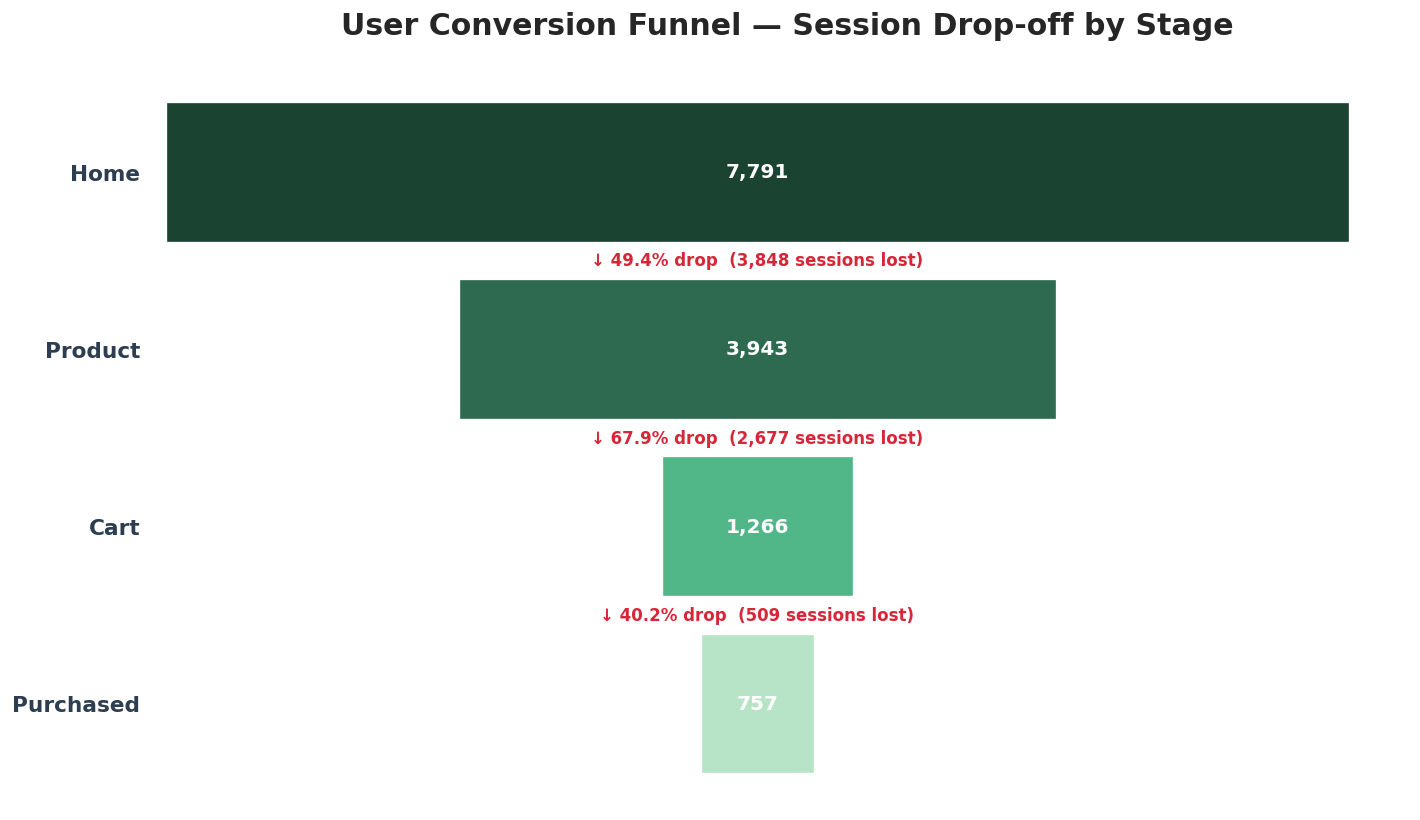

In [15]:
funnel_counts = {
    'Home'      : len(df[df['PageType'] == 'Home']),
    'Product'   : len(df[df['PageType'] == 'Product']),
    'Cart'      : len(df[df['PageType'] == 'Cart']),
    'Purchased' : int(df['Purchased'].sum())
}

stages = list(funnel_counts.keys())
counts = list(funnel_counts.values())

funnel_df            = pd.DataFrame({'Stage': stages, 'Sessions': counts})
max_sessions         = funnel_df['Sessions'].max()
funnel_df['left']    = (max_sessions - funnel_df['Sessions']) / 2
funnel_df            = funnel_df.iloc[::-1].reset_index(drop=True)

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax   = plt.subplots(figsize=(12, 7), facecolor='white')
bar_colors = ['#B7E4C7', '#52B788', '#2D6A4F', '#1B4332']
font_main  = {'family': 'DejaVu Sans', 'weight': 'bold'}

# ── BARS ──────────────────────────────────────────────────────────────────────
ax.barh(funnel_df['Stage'], funnel_df['Sessions'],
        left=funnel_df['left'],
        color=bar_colors, edgecolor='white', linewidth=2)

# ── SESSION LABELS─────────────────────────────────────────────────────────────
for i, row in funnel_df.iterrows():
    bar_mid = row['left'] + row['Sessions'] / 2
    ax.text(bar_mid, i,
            f"{int(row['Sessions']):,}",
            va='center', ha='center',
            color='white', fontsize=12, fontdict=font_main,
            clip_on=False)

# ── DROP-OFF LABELS BETWEEN BARS ──────────────────────────────────────────────
for i in range(len(funnel_df) - 1, 0, -1):
    curr     = funnel_df.loc[i, 'Sessions']
    nxt      = funnel_df.loc[i-1, 'Sessions']
    lost     = curr - nxt
    lost_pct = lost / curr * 100

    ax.text(max_sessions / 2, i - 0.5,
            f"↓ {lost_pct:.1f}% drop  ({lost:,} sessions lost)",
            ha='center', va='center',
            fontsize=10, color='#D72638', fontdict=font_main,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=2),
            clip_on=False)

# ── POLISH ────────────────────────────────────────────────────────────────────
ax.set_title('User Conversion Funnel — Session Drop-off by Stage',
             fontsize=18, pad=20, fontdict=font_main)
ax.set_xticks([])
ax.grid(False)
for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_visible(False)

ax.tick_params(axis='y', labelsize=13, length=0, pad=15)
for label in ax.get_yticklabels():
    label.set_weight('bold')
    label.set_color('#2C3E50')

plt.tight_layout()
plt.show()

**Observation:**

The biggest drop occurs between the Product Page and Cart stage.
  - **50.6%** of sessions move from Home to the Product Page
  - But only **32.1%** of those continue to the Cart
  - This results in a drop of **67.9%** — the steepest in the entire funnel

**Behavior Pattern:**

Once users reach the Cart, purchase intent strengthens considerably:

  - Nearly 60% of Cart sessions result in a completed purchase
  - This is the healthiest conversion rate across all funnel transitions
  - Suggesting the checkout experience is not a major friction point

**Business Insight:**

The core issue is not at checkout — it is much earlier in the funnel.<br>
The Home → Product and Product → Cart transitions are where the majority
of sessions are lost. Improving product discovery and page engagement
should be the primary focus before optimizing checkout.

## 2.2 Conversion Rate by Device Type

Does the device a user visits from affect their likelihood to purchase?

In [16]:
# ── FUNNEL STAGE ORDER ────────────────────────────────────────────────────────
funnel_steps = ['Home', 'Product', 'Cart', 'Purchased']

# ── BASE SESSION COUNT ────────────────────────────────────────────────────────
device_funnel = (
    df.groupby(['DeviceType', 'PageType'])['SessionID']
      .count()
      .reset_index(name='Sessions')
)

# Add Purchased as a funnel stage
purchased_stage = (
    df[df['Purchased'] == True]
      .groupby('DeviceType')['SessionID']
      .count()
      .reset_index(name='Sessions')
)
purchased_stage['PageType'] = 'Purchased'
device_funnel = pd.concat([device_funnel, purchased_stage], ignore_index=True)

# ── BASE PIVOT ────────────────────────────────────────────────────────────────
pivot = (
    device_funnel.pivot(index='PageType', columns='DeviceType', values='Sessions')
    .reindex(funnel_steps)
)
pivot.columns.name = None
pivot.index.name   = None

# ── TABLE 1 — SESSION VOLUME ──────────────────────────────────────────────────
t1 = pivot.copy()
t1['Total'] = t1.sum(axis=1)

print("Table 1 — Session Volume by Device Type and Funnel Stage")
print("─" * 52)
print(t1.to_string())
print()

# ── TABLE 2 — STEP-TO-STEP CONVERSION % ──────────────────────────────────────
t2 = (pivot.shift(-1) / pivot * 100).round(2)
t2.loc['Purchased'] = np.nan
t2 = t2.rename(index={
    'Home'      : 'Home → Product',
    'Product'   : 'Product → Cart',
    'Cart'      : 'Cart → Purchase',
    'Purchased' : '-'
})

print("Table 2 — Step-to-Step Conversion Rate by Device Type (%)")
print("─" * 52)
print(t2.to_string(na_rep='-'))
print()

# ── TABLE 3 — DROP-OFF % ──────────────────────────────────────────────────────
t3 = ((pivot - pivot.shift(-1)) / pivot * 100).round(2)
t3.loc['Purchased'] = np.nan
t3 = t3.rename(index={
    'Home'      : 'Home → Product',
    'Product'   : 'Product → Cart',
    'Cart'      : 'Cart → Purchase',
    'Purchased' : '-'
})

print("Table 3 — Funnel Drop-off Rate by Device Type (%)")
print("─" * 52)
print(t3.to_string(na_rep='-'))
print()

# ── TABLE 4 — OVERALL CONVERSION FROM HOME % ──────────────────────────────────
t4 = (pivot / pivot.loc['Home'] * 100).round(2)

print("Table 4 — Overall Survival Rate from Home by Device Type (%)")
print("─" * 52)
print(t4.to_string())

Table 1 — Session Volume by Device Type and Funnel Stage
────────────────────────────────────────────────────
           Desktop  Mobile  Tablet  Total
Home          2344    4603     844   7791
Product       1177    2401     365   3943
Cart           376     769     121   1266
Purchased      231     448      78    757

Table 2 — Step-to-Step Conversion Rate by Device Type (%)
────────────────────────────────────────────────────
                 Desktop  Mobile  Tablet
Home → Product     50.21   52.16   43.25
Product → Cart     31.95   32.03   33.15
Cart → Purchase    61.44   58.26   64.46
-                      -       -       -

Table 3 — Funnel Drop-off Rate by Device Type (%)
────────────────────────────────────────────────────
                 Desktop  Mobile  Tablet
Home → Product     49.79   47.84   56.75
Product → Cart     68.05   67.97   66.85
Cart → Purchase    38.56   41.74   35.54
-                      -       -       -

Table 4 — Overall Survival Rate from Home by Device T

### 2.2.1 Device-wise Funnel Performance

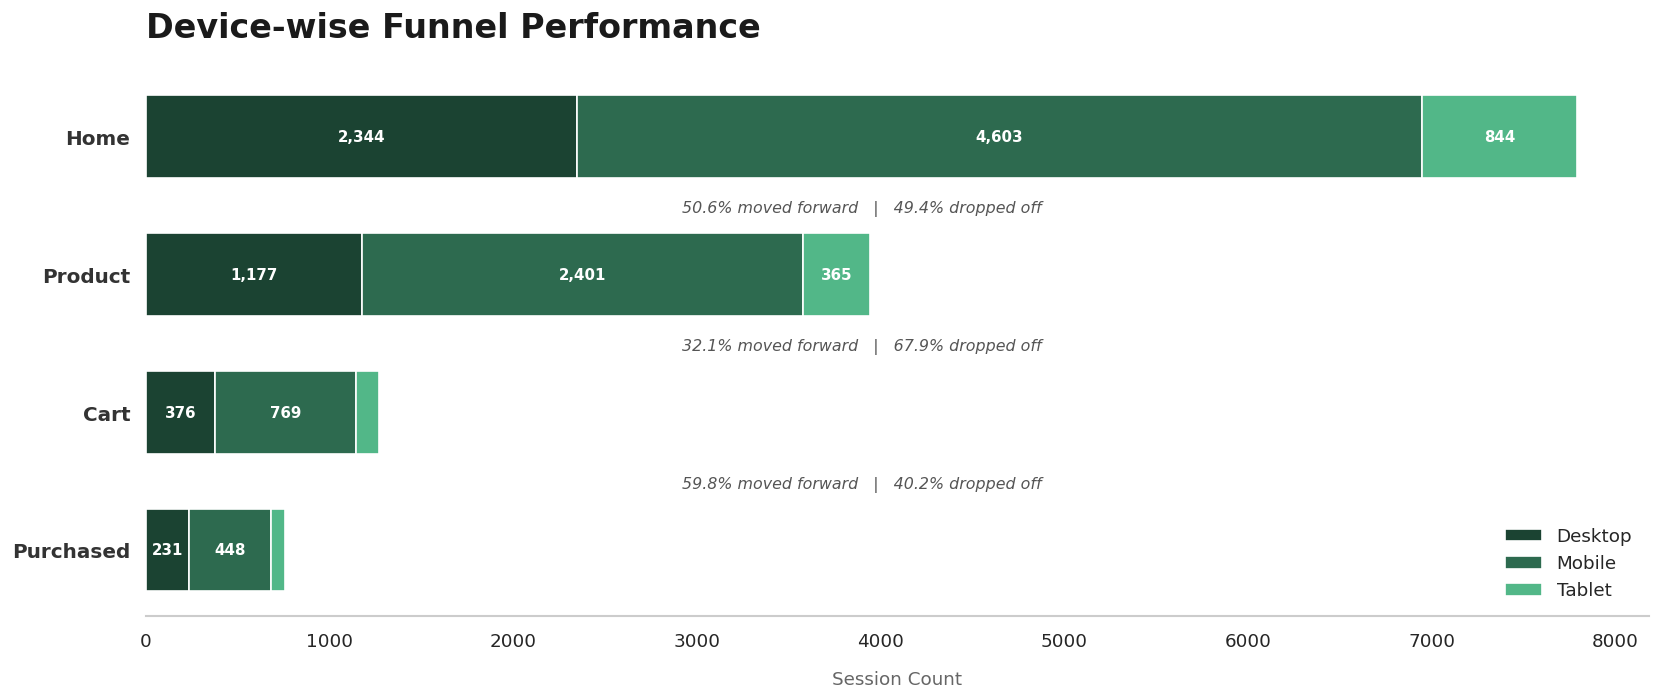

In [17]:
sns.set_theme(style='white', rc={'font.family': 'sans-serif'})
colors = {'Desktop': '#1B4332', 'Mobile': '#2D6A4F', 'Tablet': '#52B788'}

# ── CHART 1 — DEVICE-WISE FUNNEL PERFORMANCE ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6), facecolor='white')

y_pos        = np.arange(len(funnel_steps))
bottom       = np.zeros(len(funnel_steps))
total_widths = pivot.sum(axis=1).values

for device in pivot.columns:
    vals = pivot[device].values
    ax.barh(y_pos, vals, left=bottom, label=device,
            color=colors.get(device), height=0.6,
            edgecolor='white', linewidth=1)

    # Session count inside each segment
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 150:
            ax.text(b + v/2, j, f'{v:,}',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottom += vals

# Inline conversion + drop-off text between stages
for i in range(len(funnel_steps) - 1):
    conv = (total_widths[i+1] / total_widths[i]) * 100
    drop = 100 - conv
    ax.text(total_widths[0] / 2, i + 0.52,
            f'{conv:.1f}% moved forward   |   {drop:.1f}% dropped off',
            ha='center', va='center',
            fontsize=9.5, color='#555555', style='italic')

ax.set_yticks(y_pos)
ax.set_yticklabels(funnel_steps, fontsize=12, fontweight='bold', color='#333333')
ax.invert_yaxis()
ax.set_xlim(0, total_widths[0] * 1.05)
ax.set_xlabel('Session Count', fontsize=11, labelpad=12, color='#666666')
ax.set_title('Device-wise Funnel Performance',
             fontsize=20, fontweight='bold', pad=20, loc='left', color='#1A1A1A')
ax.legend(frameon=False, loc='lower right', fontsize=11)

for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.show()

### 2.2.2 Funnel Drop-off Heatmap

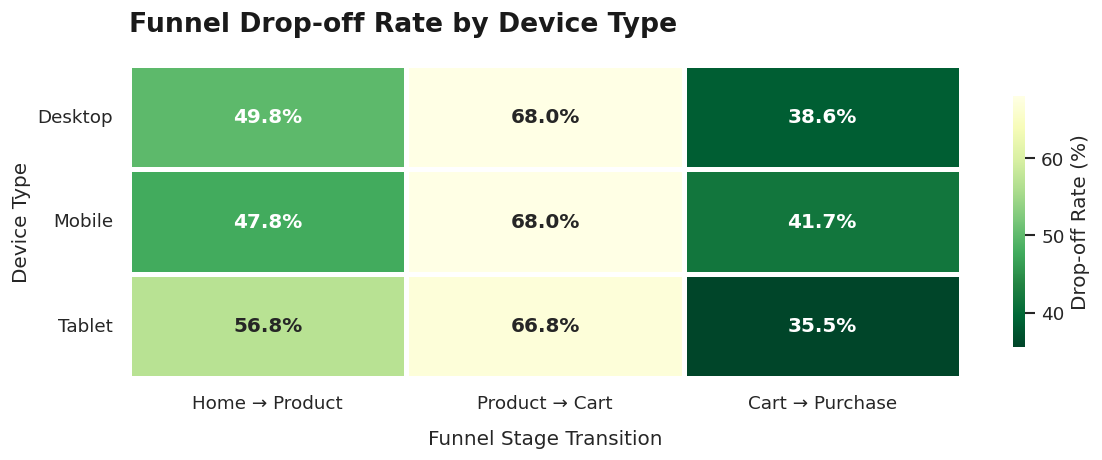

In [18]:
# ── CHART 2 — DROP-OFF HEATMAP ────────────────────────────────────────────────
# Derive drop-off % from pivot
t3 = ((pivot - pivot.shift(-1)) / pivot * 100).round(2)
t3 = t3.iloc[:-1]
t3.index = ['Home → Product', 'Product → Cart', 'Cart → Purchase']

fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')

sns.heatmap(t3.T,
            annot=True, fmt='.1f',
            cmap='YlGn_r',
            linewidths=2, linecolor='white',
            cbar_kws={'label': 'Drop-off Rate (%)', 'shrink': 0.8},
            annot_kws={'size': 12, 'weight': 'bold'},
            ax=ax)

# Append % to all annotations
for text in ax.texts:
    text.set_text(text.get_text() + '%')

ax.set_title('Funnel Drop-off Rate by Device Type',
             fontsize=16, fontweight='bold', pad=20, loc='left', color='#1A1A1A')
ax.set_xlabel('Funnel Stage Transition', fontsize=12, labelpad=10)
ax.set_ylabel('Device Type', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Statistical Validation — Chi-Square Test**<br>
─────────────────────────────────────────<br>
Since conversion rates across device types appear similar (Desktop 9.85%, Mobile 9.73%, Tablet 9.24%), we run a Chi-Square test to statistically confirm whether these differences are real or due to chance.

**Hypothesis:**<br>
H0 : Device type has no effect on conversion<br>
H1 : Device type has a significant effect on conversion

Significance level : 0.05

In [19]:
# ── CHI-SQUARE TEST — DEVICE TYPE VS PURCHASED ────────────────────────────────
contingency_table = pd.crosstab(df['DeviceType'], df['Purchased'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test — Device Type vs Conversion\n")
print(f"  Chi-Square Statistic : {chi2:.4f}")
print(f"  p-value              : {p:.4f}")
print(f"  Degrees of Freedom   : {dof}")
print()
if p > 0.05:
    print("  Result → Fail to reject H0 (p > 0.05)")
    print("  Device type does not have a statistically significant effect on conversion.")
else:
    print("  Result → Reject H0 (p ≤ 0.05)")
    print("  Device type has a statistically significant effect on conversion.")

Chi-Square Test — Device Type vs Conversion

  Chi-Square Statistic : 0.1321
  p-value              : 0.9361
  Degrees of Freedom   : 2

  Result → Fail to reject H0 (p > 0.05)
  Device type does not have a statistically significant effect on conversion.


- p-value of 0.9361 is well above the 0.05 threshold — we fail to
reject H0.
- **The device type has no effect on conversion**

### 2.2.3 Cart Abandonment by Device

In [20]:
# ── CART ABANDONMENT BY DEVICE TYPE ──────────────────────────────────────────
cart_sessions = df[df['PageType'] == 'Cart']

abandonment = cart_sessions.groupby('DeviceType')['Purchased'].agg(
    Cart_Sessions = 'count',
    Purchased     = 'sum'
).reset_index()

abandonment['Abandoned']      = abandonment['Cart_Sessions'] - abandonment['Purchased']
abandonment['Abandonment %']  = (abandonment['Abandoned'] /
                                  abandonment['Cart_Sessions'] * 100).round(2)
abandonment = abandonment.sort_values('Abandonment %', ascending=False).reset_index(drop=True)

print("Cart Abandonment by Device Type\n")
print("─" * 52)
print(abandonment.to_string(index=False))

Cart Abandonment by Device Type

────────────────────────────────────────────────────
DeviceType  Cart_Sessions  Purchased  Abandoned  Abandonment %
    Mobile            769        448        321          41.74
   Desktop            376        231        145          38.56
    Tablet            121         78         43          35.54


  - Mobile has the highest cart abandonment at 41.7% — despite being the dominant device.
  - Improving the mobile checkout experience could directly reduce abandonment and lift overall conversion

## 2.3 Conversion Rate by Referral Source

Which traffic source brings users most likely to convert —
Direct, Ads, or Social?

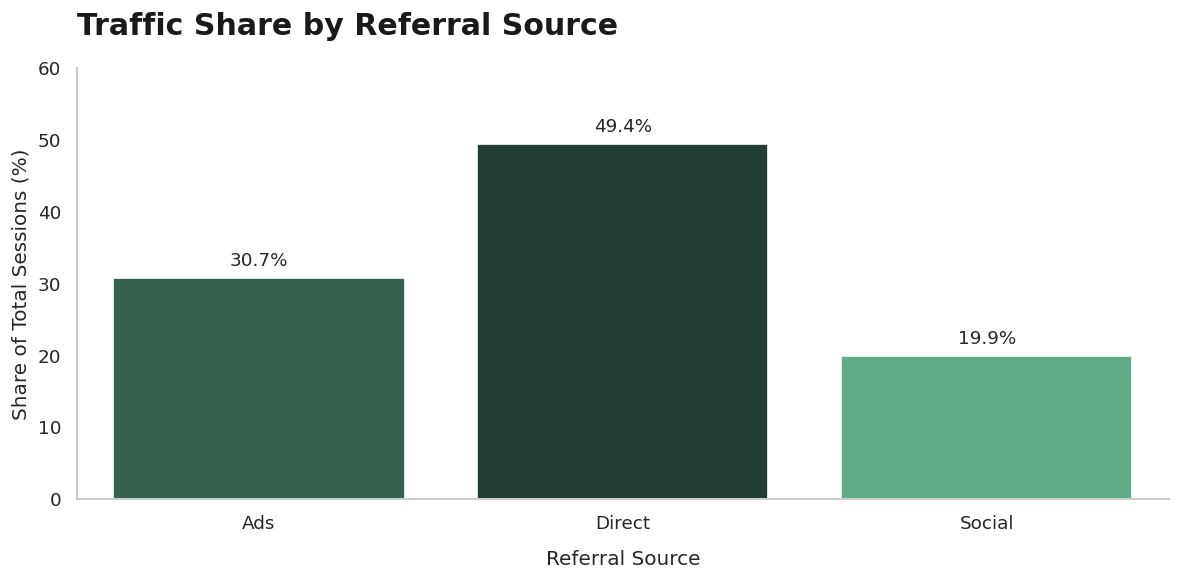

In [21]:
# ── TRAFFIC SHARE ─────────────────────────────────────────────────────────────
traffic = df.groupby('ReferralSource')['SessionID'].count().reset_index(name='Sessions')
traffic['Share %'] = (traffic['Sessions'] / traffic['Sessions'].sum() * 100).round(1)
traffic = traffic.sort_values('Sessions', ascending=False).reset_index(drop=True)

# ── BAR CHART ─────────────────────────────────────────────────────────────────
sns.set_theme(style='white', rc={'font.family': 'sans-serif'})
font_main  = {'family': 'DejaVu Sans', 'weight': 'bold'}
colors_ref = {'Direct': '#1B4332', 'Ads': '#2D6A4F', 'Social': '#52B788'}

fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')

sns.barplot(data=traffic,
            x='ReferralSource',
            y='Share %',
            palette=colors_ref,
            hue='ReferralSource',
            legend=False,
            ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=11, padding=5)

ax.set_title('Traffic Share by Referral Source',
             fontsize=18, fontweight='bold', pad=20, loc='left', color='#1A1A1A')
ax.set_xlabel('Referral Source', fontsize=12, labelpad=10)
ax.set_ylabel('Share of Total Sessions (%)', fontsize=12)
ax.set_ylim(0, 60)

for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.show()

In [22]:
# ── SESSION VOLUME PIVOT ──────────────────────────────────────────────────────
funnel_steps    = ['Home', 'Product', 'Cart', 'Purchased']

referral_funnel = (
    df.groupby(['ReferralSource', 'PageType'])['SessionID']
      .count()
      .reset_index(name='Sessions')
)
purchased_stage = (
    df[df['Purchased'] == True]
      .groupby('ReferralSource')['SessionID']
      .count()
      .reset_index(name='Sessions')
)
purchased_stage['PageType'] = 'Purchased'
referral_funnel = pd.concat([referral_funnel, purchased_stage], ignore_index=True)

pivot_ref = (
    referral_funnel.pivot(index='PageType', columns='ReferralSource', values='Sessions')
    .reindex(funnel_steps)
)
pivot_ref.columns.name = None
pivot_ref.index.name   = None
pivot_ref['Total']     = pivot_ref.sum(axis=1)

print("Table 1 — Session Volume by Referral Source and Funnel Stage")
print("─" * 52)
print(pivot_ref.to_string())
print()

# ── STEP-TO-STEP CONVERSION % PER SOURCE ─────────────────────────────────────
ref_counts  = pivot_ref.drop(columns='Total')

ads_conv    = 100 * (ref_counts['Ads'].shift(-1)    / ref_counts['Ads'])
direct_conv = 100 * (ref_counts['Direct'].shift(-1) / ref_counts['Direct'])
social_conv = 100 * (ref_counts['Social'].shift(-1) / ref_counts['Social'])

step_conv = pd.DataFrame({
    'Step'     : ['Home → Product', 'Product → Cart', 'Cart → Purchase'],
    'Ads_%'    : ads_conv.values[:-1].round(2),
    'Direct_%' : direct_conv.values[:-1].round(2),
    'Social_%' : social_conv.values[:-1].round(2)
})

print("Table 2 — Step-to-Step Conversion Rate by Referral Source (%)")
print("─" * 52)
print(step_conv.to_string(index=False))

Table 1 — Session Volume by Referral Source and Funnel Stage
────────────────────────────────────────────────────
            Ads  Direct  Social  Total
Home       2413    3845    1533   7791
Product    1212    1930     801   3943
Cart        365     645     256   1266
Purchased   214     401     142    757

Table 2 — Step-to-Step Conversion Rate by Referral Source (%)
────────────────────────────────────────────────────
           Step  Ads_%  Direct_%  Social_%
 Home → Product  50.23     50.20     52.25
 Product → Cart  30.12     33.42     31.96
Cart → Purchase  58.63     62.17     55.47


In [23]:
# Calculate session-level conversion by referral source
ref_conv = (
    df.groupby('ReferralSource')['Purchased']
      .mean()
      .reset_index()
      .sort_values('Purchased', ascending=False)
)

# Display table
print("Conversion Rate by Referral Source:")
display(ref_conv.style.format({'Purchased': '{:.2%}'}))

Conversion Rate by Referral Source:


,ReferralSource,Purchased
1,Direct,6.25%
2,Social,5.48%
0,Ads,5.36%


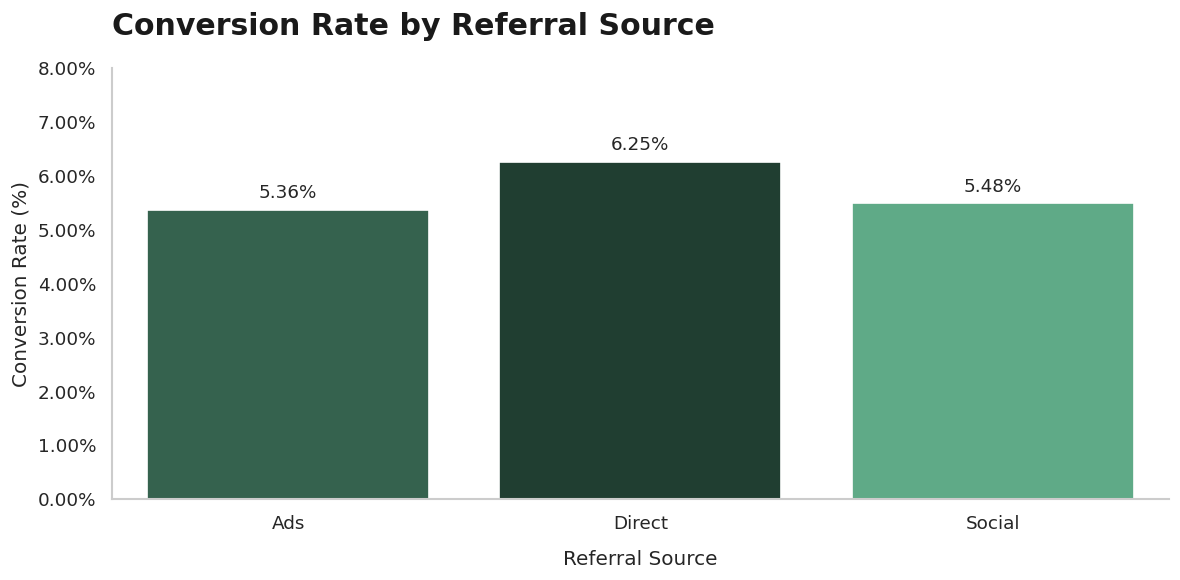

In [24]:
sns.set_theme(style='white', rc={'font.family': 'sans-serif'})
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')

sns.barplot(data=ref_conv,
            x='ReferralSource',
            y='Purchased',
            palette=colors_ref,
            hue='ReferralSource',
            legend=False,
            ax=ax)

for container in ax.containers:
    labels = [f'{h * 100:.2f}%' for h in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='edge', fontsize=11, padding=5)

ax.set_title('Conversion Rate by Referral Source',
             fontsize=18, fontweight='bold', pad=20, loc='left', color='#1A1A1A')
ax.set_xlabel('Referral Source', fontsize=12, labelpad=10)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_ylim(0, 0.08)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=2))

for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.show()

**Statistical Validation — Chi-Square Test**<br>
─────────────────────────────────────────<br>
Since conversion rates appear consistent across referral sources
with no dramatic differences (Direct 6.25%, Social	5.48%, Ads	5.36%), we run a Chi-Square test to statistically confirm whether the observed variation is
meaningful or simply due to chance.

**Hypothesis:**<br>
  H0 : Referral source has no effect on purchase conversion<br>
  H1 : Referral source has a significant effect on purchase conversion

  Significance level : 0.05

In [25]:
# ── CHI-SQUARE TEST — REFERRAL SOURCE VS PURCHASED ────────────────────────────
contingency_ref = pd.crosstab(df['ReferralSource'], df['Purchased'])

chi2, p, dof, expected = chi2_contingency(contingency_ref)

print("Chi-Square Test — Referral Source vs Conversion\n")
print(f"  Chi-Square Statistic : {chi2:.4f}")
print(f"  p-value              : {p:.4f}")
print(f"  Degrees of Freedom   : {dof}")
print()
if p > 0.05:
    print("  Result → Fail to reject H0 (p > 0.05)")
    print("  Referral source does not have a statistically significant effect on conversion.")
else:
    print("  Result → Reject H0 (p ≤ 0.05)")
    print("  Referral source has a statistically significant effect on conversion.")

Chi-Square Test — Referral Source vs Conversion

  Chi-Square Statistic : 4.1797
  p-value              : 0.1237
  Degrees of Freedom   : 2

  Result → Fail to reject H0 (p > 0.05)
  Referral source does not have a statistically significant effect on conversion.


- p-value of 0.1237 is above the 0.05 threshold — we fail to
reject H0.
- **The difference in conversion rates across referral sources is not statistically significant.**



## 2.4 Behavioral Analysis

Do users who spend more time on the platform
or add more items to cart convert at a higher rate?

### Normality check — histogram for both variables

Text(0.5, 1.0, 'ItemsInCart Distribution')

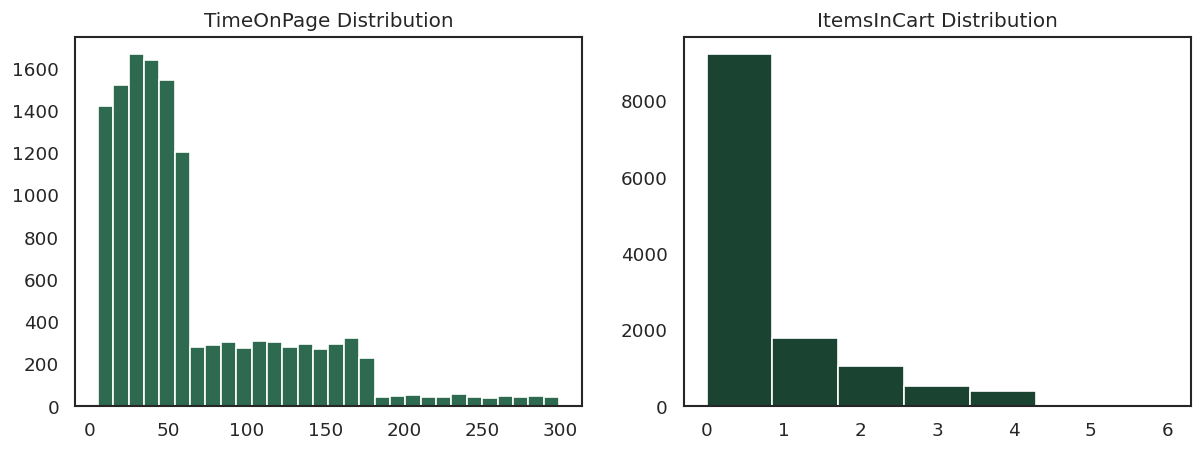

In [26]:
# Quick normality check — visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['TimeOnPage_seconds'], bins=30, color='#2D6A4F', edgecolor='white')
axes[0].set_title('TimeOnPage Distribution')

axes[1].hist(df['ItemsInCart'], bins=7, color='#1B4332', edgecolor='white')
axes[1].set_title('ItemsInCart Distribution')

Neither variables follows a normal distribution — Mann-Whitney U (non-parametric)
is used throughout this section instead of a T-test.

### 2.4.1 Time on Page

In [27]:
# ── TIME ON PAGE — SUMMARY STATS ─────────────────────────────────────────────
df['Purchase Status'] = df['Purchased'].map({True: 'Purchased', False: 'Not Purchased'})

print("Time on Page — Summary Statistics by Purchase Outcome\n")
print("─" * 52)
top_stats = df.groupby('Purchase Status')['TimeOnPage_seconds'].agg(
    Mean   = 'mean',
    Median = 'median',
    Std    = 'std',
    Min    = 'min',
    Max    = 'max'
).round(2)
print(top_stats.to_string())

Time on Page — Summary Statistics by Purchase Outcome

────────────────────────────────────────────────────
                  Mean  Median   Std  Min  Max
Purchase Status                               
Not Purchased    59.60   44.00 50.34    5  298
Purchased       165.18  167.00 78.25   30  299


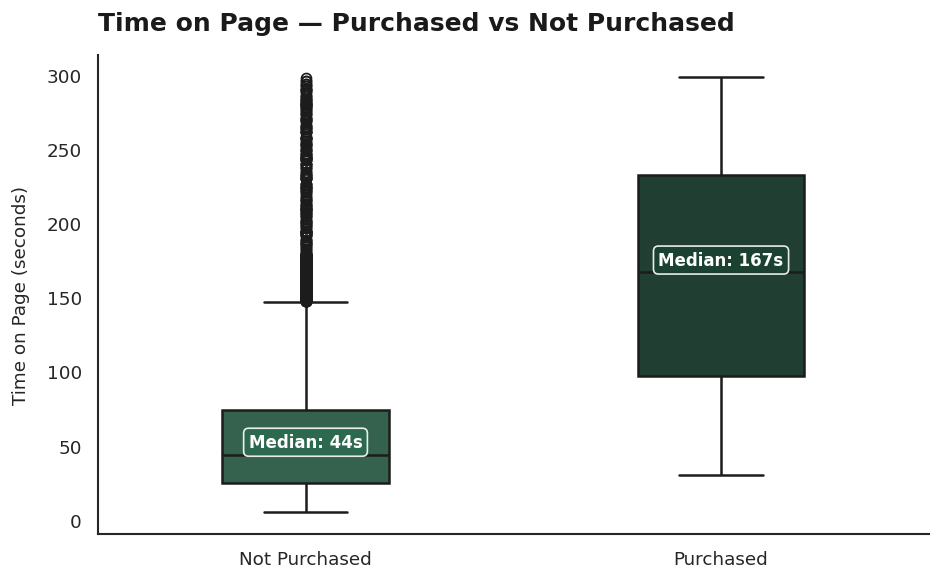

In [28]:
# ── BOXPLOT — TIME ON PAGE BY PURCHASE STATUS ─────────────────────────────────
sns.set_theme(style='white', rc={'font.family': 'sans-serif'})
font_main  = {'family': 'DejaVu Sans', 'weight': 'bold'}
colors_box = {'Not Purchased': '#2D6A4F', 'Purchased': '#1B4332'}

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')

sns.boxplot(data=df, x='Purchase Status', y='TimeOnPage_seconds',
            palette=colors_box, width=0.4,
            order=['Not Purchased', 'Purchased'],
            linewidth=1.5, ax=ax)

medians = df.groupby('Purchase Status')['TimeOnPage_seconds'].median()
for i, status in enumerate(['Not Purchased', 'Purchased']):
    ax.text(i, medians[status] + 5,
            f'Median: {medians[status]:.0f}s',
            ha='center', fontsize=10, fontdict=font_main, color='white',
            bbox=dict(boxstyle='round,pad=0.3',
                      fc=list(colors_box.values())[i], alpha=0.9))

ax.set_title('Time on Page — Purchased vs Not Purchased',
             fontsize=15, fontweight='bold', pad=15, loc='left', color='#1A1A1A')
ax.set_xlabel('')
ax.set_ylabel('Time on Page (seconds)', fontsize=11, labelpad=10)

for side in ['top', 'right']:
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

**Statistical Validation — Mann-Whitney U test**<br>
─────────────────────────────────────────<br>
The median time on page for purchasers (167s) is dramatically
higher than non-purchasers (44s). We run a Mann-Whitney U test
to confirm this difference is statistically significant.

**Hypothesis:**<br>
  H0 : Time on page is the same for purchasers and non-purchasers<br>
  H1 : Time on page differs significantly between the two groups

  Significance level : 0.05

In [29]:
# ── MANN-WHITNEY U — TIME ON PAGE ─────────────────────────────────────────────
purchased     = df[df['Purchased'] == True]['TimeOnPage_seconds']
not_purchased = df[df['Purchased'] == False]['TimeOnPage_seconds']

stat, p = mannwhitneyu(purchased, not_purchased, alternative='two-sided')

print("Mann-Whitney U Test — Time on Page vs Purchase Outcome\n")
print(f"  U Statistic : {stat:,.2f}")
print(f"  p-value     : {p:.6f}")
print()
if p < 0.05:
    print("  Result → Reject H0 (p < 0.05)")
    print("  Time on page is significantly different between purchasers and non-purchasers.")
else:
    print("  Result → Fail to reject H0 (p > 0.05)")

Mann-Whitney U Test — Time on Page vs Purchase Outcome

  U Statistic : 8,112,583.50
  p-value     : 0.000000

  Result → Reject H0 (p < 0.05)
  Time on page is significantly different between purchasers and non-purchasers.


- p-value of 0.00 is less than the 0.05 threshold — H0 Rejected.
- **The difference is statistically significant.**
- Purchasers have a median time on page of 167s vs 44s for non-purchasers — 3.8x higher
- This makes sense, as purchasers go through the entire funnel, which naturally takes more time.

### 2.4.2 Items in Cart

In [30]:
# ── CART SIZE ANALYSIS ────────────────────────────────────────────────────────
cart_analysis = df.groupby('ItemsInCart').agg(
    Sessions  = ('SessionID', 'count'),
    Purchases = ('Purchased', 'sum')
).reset_index()
cart_analysis['Conversion %'] = (
    cart_analysis['Purchases'] / cart_analysis['Sessions'] * 100
).round(2)

print("Cart Size — Session Volume and Conversion Rate\n")
print("─" * 50)
print(cart_analysis.to_string(index=False))

Cart Size — Session Volume and Conversion Rate

──────────────────────────────────────────────────
 ItemsInCart  Sessions  Purchases  Conversion %
           0      9226          0          0.00
           1      1789        178          9.95
           2      1050        203         19.33
           3       533        180         33.77
           4       388        196         50.52
           5        11          0          0.00
           6         3          0          0.00


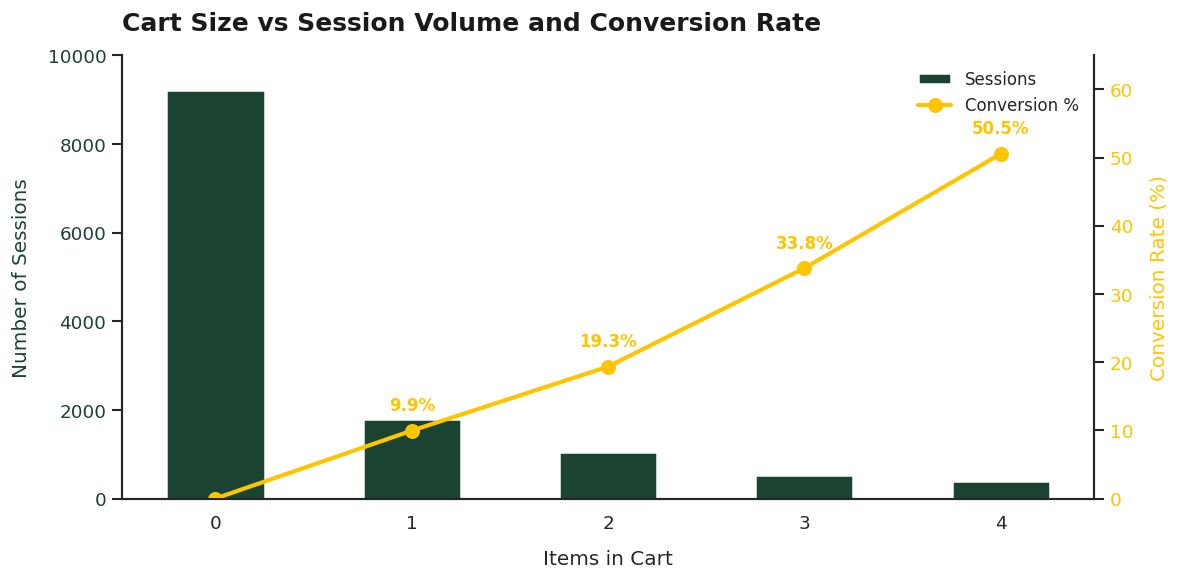

In [31]:
# ── DUAL AXIS — CART SIZE VS VOLUME AND CONVERSION % ─────────────────────────
cart_plot = cart_analysis[cart_analysis['ItemsInCart'] <= 4]

fig, ax1 = plt.subplots(figsize=(10, 5), facecolor='white')

# Bars — session volume
ax1.bar(cart_plot['ItemsInCart'],
        cart_plot['Sessions'],
        color='#1B4332', edgecolor='white',
        linewidth=1.5, width=0.5, label='Sessions')

ax1.set_xlabel('Items in Cart', fontsize=12, labelpad=10)
ax1.set_ylabel('Number of Sessions', fontsize=12, labelpad=10, color='#1B4332')
ax1.tick_params(axis='y', labelcolor='#1B4332')
ax1.set_ylim(0, 10000)

# Line — conversion %
ax2 = ax1.twinx()
ax2.plot(cart_plot['ItemsInCart'],
         cart_plot['Conversion %'],
         color='#FDC500', linewidth=2.5,
         marker='o', markersize=8,
         label='Conversion %')

# Annotate conversion % values on line
for _, row in cart_plot.iterrows():
    if row['Conversion %'] > 0:
        ax2.text(row['ItemsInCart'], row['Conversion %'] + 3,
                 f"{row['Conversion %']:.1f}%",
                 ha='center', fontsize=10,
                 fontweight='bold', color='#FDC500')
ax2.set_ylabel('Conversion Rate (%)', fontsize=12, labelpad=10, color='#FDC500')
ax2.tick_params(axis='y', labelcolor='#FDC500')
ax2.set_ylim(0, 65)

ax1.set_title('Cart Size vs Session Volume and Conversion Rate',
              fontsize=15, fontweight='bold', pad=15, loc='left', color='#1A1A1A')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           frameon=False, fontsize=10, loc='upper right')

for side in ['top']:
    ax1.spines[side].set_visible(False)
    ax2.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

**Key Observations:**
- Conversion rate grows steadily with cart size
- A user with 4 items is 5x more likely to convert than a user with just 1 item

**Business Insight:**

- Get users to add at least one item — Prominent "Add to Cart"
     prompts and personalised product recommendations on the Product page can help drive this.
- Encourage users to add more items — bundle deals, "Frequently Bought Together" suggestions, or multi-item discounts can increase cart size and directly lift conversion rate.

## 2.5 Time Trend Analysis

Do conversion rates vary across months or days of the week?
Identifying time-based patterns can help target campaigns
and allocate resources more effectively.

In [32]:
# ── TIME FEATURES ─────────────────────────────────────────────────────────────
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday',
               'Saturday','Sunday']

# Monthly aggregation
monthly = df.groupby('Month')['Purchased'].agg(
    Sessions  = 'count',
    Purchases = 'sum'
).reset_index()
monthly['Conversion %'] = (monthly['Purchases'] / monthly['Sessions'] * 100).round(2)
monthly['Month']         = pd.Categorical(monthly['Month'],
                            categories=month_order, ordered=True)
monthly = monthly.sort_values('Month')

# Day of week aggregation
daily = df.groupby('DayOfWeek')['Purchased'].agg(
    Sessions  = 'count',
    Purchases = 'sum'
).reset_index()
daily['Conversion %'] = (daily['Purchases'] / daily['Sessions'] * 100).round(2)
daily['DayOfWeek']     = pd.Categorical(daily['DayOfWeek'],
                          categories=day_order, ordered=True)
daily = daily.sort_values('DayOfWeek')

overall = df['Purchased'].mean() * 100

### 2.5.1 Monthly Conversion Trend

In [33]:
print("Monthly Session Volume and Conversion Rate\n")
print("─" * 48)
print(monthly[['Month','Sessions','Purchases','Conversion %']].to_string(index=False))
print(f"\n  Overall Average : {overall:.2f}%")

Monthly Session Volume and Conversion Rate

────────────────────────────────────────────────
    Month  Sessions  Purchases  Conversion %
  January      1088         65          5.97
 February      1136         55          4.84
    March      1073         68          6.34
    April      1044         55          5.27
      May      1119         86          7.69
     June      1160         70          6.03
     July      1047         73          6.97
   August      1057         64          6.05
September      1090         58          5.32
  October      1073         51          4.75
 November      1038         63          6.07
 December      1075         49          4.56

  Overall Average : 5.82%


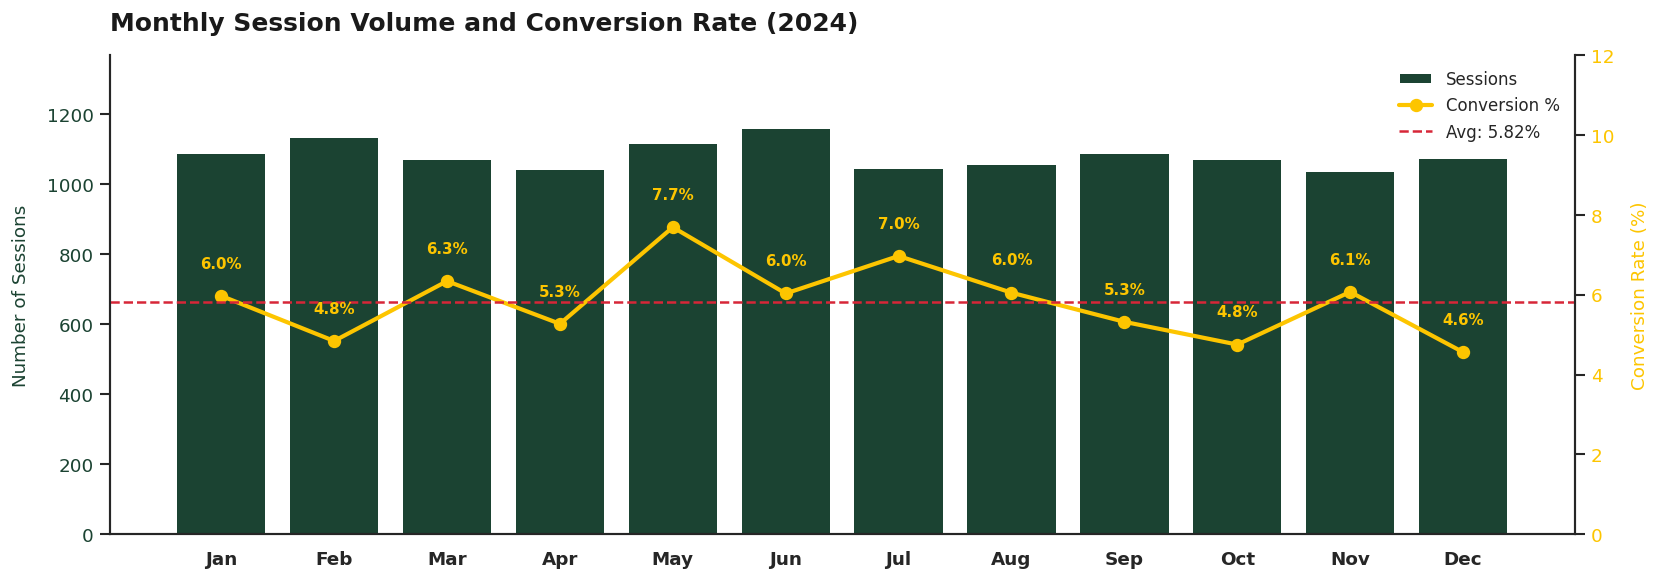

In [34]:
# ── DUAL AXIS — MONTHLY SESSIONS + CONVERSION % ───────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5), facecolor='white')
font_main = {'family': 'DejaVu Sans', 'weight': 'bold'}

# Bars — sessions
bar_plot = ax1.bar(range(len(monthly)), monthly['Sessions'],
        color='#1B4332', edgecolor='white',
        linewidth=1.2, label='Sessions')
ax1.set_ylabel('Number of Sessions', fontsize=11, labelpad=10, color='#1B4332')
ax1.tick_params(axis='y', labelcolor='#1B4332')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(
    [m[:3] for m in month_order],
    fontsize=11, fontweight='bold'
)


ax1.set_ylim(0, monthly['Sessions'].max() * 1.18)

ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly['Conversion %'],
         color='#FDC500', linewidth=2.5,
         marker='o', markersize=7, label='Conversion %')
ax2.axhline(overall, color='#D72638', linewidth=1.5,
            linestyle='--', label=f'Avg: {overall:.2f}%')
ax2.set_ylabel('Conversion Rate (%)', fontsize=11, labelpad=10, color='#FDC500')
ax2.tick_params(axis='y', labelcolor='#FDC500')
ax2.set_ylim(0, 12)

# Add labels for the conversion % line
for i, (month, conv_rate) in enumerate(zip(monthly['Month'], monthly['Conversion %'])):
    ax2.annotate(f'{conv_rate:.1f}%',
                 xy=(i, conv_rate),
                 xytext=(0, 15),
                 textcoords="offset points",
                 ha='center', va='bottom',
                 fontsize=9, color='#FDC500', fontweight='bold')


ax1.set_title('Monthly Session Volume and Conversion Rate (2024)',
              fontsize=15, fontweight='bold', pad=15, loc='left', color='#1A1A1A')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           frameon=False, fontsize=10, loc='upper right')

for side in ['top']:
    ax1.spines[side].set_visible(False)
    ax2.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

**Key Observations:**
  - Summer months (May–August) consistently perform
    above or at average — suggesting stronger purchase
    intent during this period
  - Conversion dips in the cooler months — February (4.84%),
    October (4.75%) and December (4.56%) are the three
    weakest months of the year
  
**Business Insight:**

  Conversion drops during winter months present a clear
  opportunity — targeted winter promotions, seasonal
  discounts or holiday campaigns could help recover
  the dip in October through December.

### 2.5.2 Conversion Rate by Day of Week

In [35]:
print("Conversion Rate by Day of Week\n")
print("─" * 45)
print(daily[['DayOfWeek','Sessions','Purchases','Conversion %']].to_string(index=False))
print(f"\n  Overall Average : {overall:.2f}%")

Conversion Rate by Day of Week

─────────────────────────────────────────────
DayOfWeek  Sessions  Purchases  Conversion %
   Monday      1899         91          4.79
  Tuesday      1834        132          7.20
Wednesday      1801        115          6.39
 Thursday      1866         99          5.31
   Friday      1865         93          4.99
 Saturday      1937        115          5.94
   Sunday      1798        112          6.23

  Overall Average : 5.82%


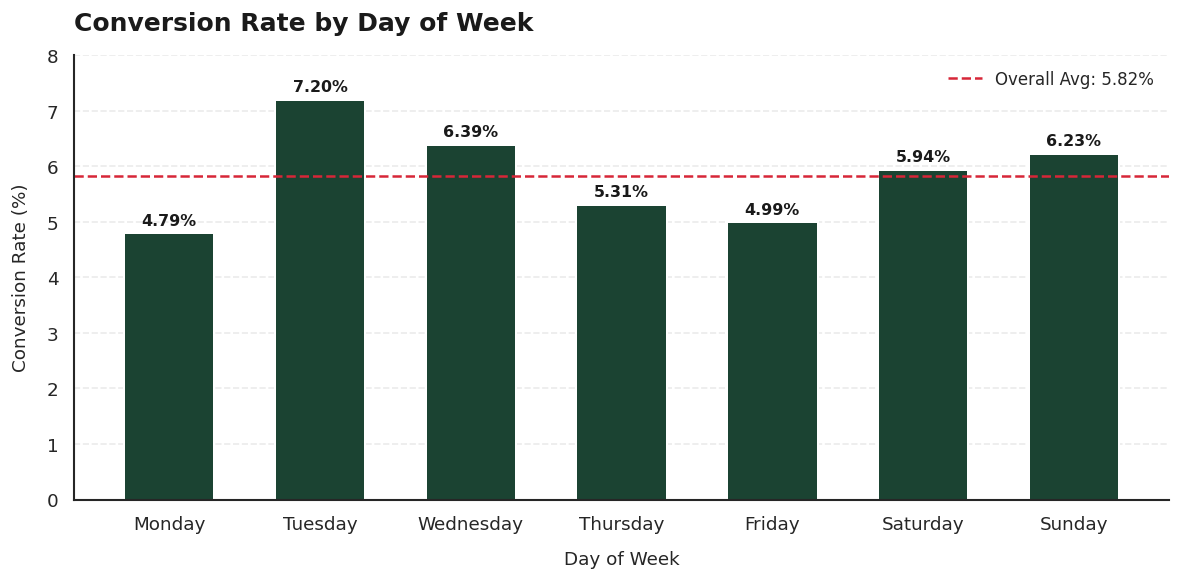

In [36]:
# ── BAR CHART — CONVERSION BY DAY (colour coded vs average) ──────────────────
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')

bar_colors = '#1B4332'

bars = ax.bar(daily['DayOfWeek'], daily['Conversion %'],
              color=bar_colors, edgecolor='white',
              linewidth=1.2, width=0.6)

for bar, val in zip(bars, daily['Conversion %']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{val:.2f}%',
            ha='center', va='bottom',
            fontsize=9.5, fontdict=font_main, color='#1A1A1A')

ax.axhline(overall, color='#D72638', linewidth=1.5,
           linestyle='--', label=f'Overall Avg: {overall:.2f}%')

ax.set_title('Conversion Rate by Day of Week',
             fontsize=15, fontweight='bold', pad=15, loc='left', color='#1A1A1A')
ax.set_xlabel('Day of Week', fontsize=11, labelpad=10)
ax.set_ylabel('Conversion Rate (%)', fontsize=11, labelpad=10)
ax.set_ylim(0, 8)

ax.legend(handles=[plt.Line2D([0],[0], color='#D72638',
          linewidth=1.5, linestyle='--',
          label=f'Overall Avg: {overall:.2f}%')],
          frameon=False, fontsize=10)

ax.grid(axis='y', linestyle='--', alpha=0.4)

for side in ['top', 'right']:
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

**Key Observations:**
  - Tuesday (7.20%) and Wednesday (6.39%) are the strongest performing days
  - Weekends (Saturday 5.94%, Sunday 6.23%) perform close to average — contrary to the expectation that users shop more on weekends


**Business Insight:**

  Weekend conversion is not as strong as expected —
  users may be browsing casually rather than purchasing.
  Focusing promotional efforts mid-week, particularly
  Tuesday and Wednesday, is likely to yield better
  returns. Weekend re-engagement campaigns could also
  help convert casual weekend browsers into buyers.

##**Final Insights & Business Actions**

---

### Core Problem


The biggest loss in the funnel occurs between **Product Page → Cart**,
where **67.9% of users drop off** — nearly 7 in 10 users who view
a product never add it to cart.

This is the single most critical issue affecting overall conversion.

---

### What is NOT the Problem


- **Device type** is not a factor — all devices show near-identical
  funnel patterns and conversion rates (p-value = 0.936)

- **Referral source** has no meaningful impact — Direct, Ads and Social
  all convert within 1% of each other (p-value = 0.124)

- **Checkout experience** is not broken — 60% of users who reach Cart
  complete the purchase, the healthiest transition in the funnel

---

### The Real Issue


Users are reaching the Product page but not taking action.

- Only 50.6% of Home visitors move to the Product page
- Of those, only 32% add items to cart
- Sessions with 0 items in cart never convert — without cart
  activity, purchase probability is zero

The problem is not traffic, device, or channel — it is
**product page engagement and cart commitment.**

---

### Key Behavioral Insight


Cart size is the strongest predictor of conversion —
and the relationship is consistent and progressive.

- 0 items in cart → 0.0% conversion
- 1 item in cart → 9.9% conversion
- 2 items in cart → 19.3% conversion
- 4 items in cart → 50.5% conversion

Every additional item added to cart significantly increases
purchase probability. The priority is twofold — get users
to add the first item, then encourage them to add more.

---

### Time & Engagement


Users who purchase spend significantly more time on page —
median **167 seconds** vs **44 seconds** for non-purchasers (p ≈ 0.000).

This confirms that engaged users do convert — the challenge
is getting more users to that level of engagement.

---

### When to Target Users


- **Mid-week performs best** — Tuesday (7.20%) and Wednesday (6.39%)
  record the highest conversion rates
- **Summer months outperform winter** — May (7.69%) and July (6.97%)
  peak, while October–December dip below average
- Scheduling campaigns and promotions mid-week and during
  summer months is likely to yield better returns

---

### What Should Be Fixed


#### 🔴 1. Product Page → Cart Transition<br>
67.9% drop-off — the biggest leak in the funnel.

- Make "Add to Cart" more prominent
- Improve product images, descriptions and trust signals
- Reduce page friction and distractions

**Priority: High | Impact: High**

<br>

####🟠 2. Increase Cart Size<br>
Conversion grows from 9.9% (1 item) to 50.5% (4 items) —
every additional item significantly lifts purchase probability.

- Introduce bundle deals and "Frequently Bought Together"
- Offer multi-item incentives (e.g. buy 2, get 10% off)

**Priority: High | Impact: High**

<br>

####🟡 3. Re-engage Cart Abandoners<br>
Users who added items but didn't purchase show the strongest
intent signal — they are closest to converting.

- Retargeting campaigns and cart reminder notifications
- Time-limited incentives to complete purchase

**Priority: Medium | Impact: High**

<br>

#### 🟢 4. Optimise Campaign Timing<br>
Tuesday–Wednesday convert best (7.20%, 6.39%).
December is the weakest month (4.56%).

- Focus campaigns mid-week
- Introduce winter promotions October–December

**Priority: Medium | Impact: Medium**

<br>

#### 🔵 5. Referral & Device — Not a Priority
No significant difference across channels (p = 0.124)
or devices (p = 0.936).

- Focus resources on product page and cart experience
- Channel and device optimisation will not move the needle

**Priority: Low | Impact: Low**

---

### Business Impact


The platform conversion rate currently stands at **5.82%.**
The funnel loses the majority of users at two early stages —
Home → Product (49.4% drop) and Product → Cart (67.9% drop).

Improving the Product page experience even marginally will
have a disproportionate impact on revenue — this is where
**12,243 non-converting sessions** are lost every year.

Small gains at this step deliver the highest return.

## Assumptions Revisited

---

**Assumption 1 — Steepest drop between Product and Cart**
✅ Supported — 67.9% drop confirmed, highest in the funnel.



**Assumption 2 — Mobile converts less than Desktop**
❌ Not Supported — All devices convert within 0.2% of each other (p = 0.936).



**Assumption 3 — More time on page → higher conversion**
✅ Supported — Purchasers spend 3.8x more time (167s vs 44s) — p ≈ 0.



**Assumption 4 — Ads convert better than other channels**
❌ Not Supported — Direct leads at 6.25%, Ads lowest at 5.36%.<br>
Difference is not statistically significant (p = 0.124).



**Assumption 5 — More items in cart → higher conversion**
✅ Supported — Conversion grows consistently from 0% (0 items)
to 50.5% (4 items). Strongest finding in the analysis.